# Riesgo Longitudinal de Reingreso Bajo un Programa de Gestión de Cuidado con PROC GEE

## Resumen Ejecutivo

Este cuaderno ajusta un modelo logístico marginal (promediado sobre la población) para un desenlace **binario de reingreso a 30 días** medido repetidamente a lo largo de cuatro visitas de seguimiento por paciente, usando **PROC GEE** para tener en cuenta la correlación dentro del paciente. En una cohorte sintética balanceada de **25 pacientes seguidos durante 4 visitas cada uno (100 registros paciente-visita)**, el modelo estima el efecto promediado sobre la población de un **programa de Gestión de Cuidado** frente al cuidado estándar, ajustando por sexo, edad, carga de comorbilidad y visita.

El ajuste con correlación intercambiable devuelve un coeficiente `factor(program)Standard` de **+2.306** en la escala logit con un error estándar empírico (sandwich) de **0.467** (Z = 4.94, p < 0.0001): los pacientes con cuidado estándar tienen probabilidades de reingreso notablemente más altas que los pacientes de Gestión de Cuidado. Exponenciando el contraste se obtiene un **odds ratio de Gestión de Cuidado frente a Estándar de 0.10 (IC de Wald del 95% de 0.040 a 0.249)** — un efecto protector fuerte y estadísticamente significativo cuyo intervalo de confianza excluye 1. Una correlación de trabajo AR(1) reproduce el mismo coeficiente (**+2.315**), y la estructura intercambiable ajusta mejor según el QIC (**111.77** frente a **123.94**), por lo que la conclusión no es un artefacto de la correlación asumida.

## Fuentes de Datos

Todos los datos se generan en línea mediante el primer paso DATA (sin archivos externos, semilla fija `101`). Una cohorte sintética, `readmit`, contiene **25 pacientes observados cada uno en 4 visitas (100 filas paciente-visita)** — un diseño longitudinal balanceado dimensionado al límite de 100 observaciones de este entorno, con `patient` como unidad de agrupamiento.

| Variable | Tipo | Descripción |
|----------|------|-------------|
| `patient` | num | ID del paciente — la unidad de agrupamiento/sujeto para las medidas repetidas |
| `visit` | num | Número de visita de seguimiento (1-4), el índice de tiempo dentro del sujeto |
| `program` | char | Programa de cuidado: `CareMgmt` (intervención) o `Standard` |
| `sex` | char | Sexo del paciente (`Female`/`Male`) |
| `age` | num | Edad en años (~50-70) |
| `age_c` | num | Edad centrada/escalada, `(age-60)/10`, la covariable del modelo |
| `comorbid` | num | Cantidad de comorbilidades (Poisson, media ~2) |
| `readmit` | num | Desenlace binario: 1 = reingresó dentro de los 30 días de la visita, si no 0 |

El modelo generador de datos incorpora un verdadero efecto protector del programa (log-odds de **-1.4** para `CareMgmt`), un riesgo creciente con la comorbilidad y la edad, una leve tendencia decreciente por visita, y un intercepto aleatorio a nivel de paciente (`u`, DE 1.1) para que las observaciones repetidas del mismo paciente estén correlacionadas positivamente — exactamente la estructura que GEE está diseñado para manejar. Los pacientes se asignan a los dos programas en alternancia para que los brazos queden balanceados (13 Gestión de Cuidado, 12 Estándar).

## Por qué un modelo marginal para esta pregunta

Los hospitales son cada vez más responsables de los **reingresos a 30 días**. Una pregunta de evaluación común es: *¿inscribir a los pacientes dados de alta en un programa de gestión de cuidado reduce su riesgo de reingreso?* Debido a que cada paciente se sigue a lo largo de varias visitas posteriores al alta, los desenlaces binarios repetidos en un mismo paciente están **correlacionados**, lo cual viola el supuesto de independencia de la regresión logística ordinaria y desinfla sus errores estándar.

**PROC GEE** (ecuaciones de estimación generalizadas) ajusta un modelo logístico *marginal*, promediado sobre la población, y corrige los errores estándar por la correlación dentro del paciente usando una matriz de correlación de trabajo más el estimador de varianza empírico (sandwich). Los coeficientes de regresión describen el efecto de una covariable **promediado sobre la población** — el objetivo natural para una pregunta de evaluación de programas.

Este cuaderno:
1. Simula una cohorte longitudinal balanceada que se ajusta al límite de 100 observaciones.
2. Ajusta un GEE logístico marginal con una correlación de trabajo intercambiable.
3. Traduce el coeficiente del programa en un odds ratio con un intervalo de confianza de Wald.
4. Compara el ajuste con una estructura AR(1) (las visitas están ordenadas en el tiempo) mediante QIC.

## Paso 1 — Simular la cohorte longitudinal

Generamos **25 pacientes, cada uno observado en 4 visitas (100 filas)**. Un intercepto aleatorio a nivel de paciente `u` induce la correlación positiva dentro del paciente que GEE debe acomodar; el predictor lineal en la escala logit codifica un efecto protector de la gestión de cuidado (-1.4), un riesgo creciente con la comorbilidad y la edad, y una leve tendencia decreciente a través de las visitas. Los pacientes se alternan entre los dos programas para que los brazos queden balanceados. `call streaminit` fija la semilla para la reproducibilidad.

In [1]:
DATOS readmit;
   LLAMAR streaminit(101);
   LONGITUD program $9 sex $6;
   HACER patient = 1 HASTA 25;
      /* La asignación alternada mantiene equilibrados los dos brazos */
      SI mod(patient, 2) = 1 ENTONCES program = "CareMgmt";
      SINO program = "Standard";
      SI rand("uniform") < 0.5 ENTONCES sex = "Female";
      SINO sex = "Male";
      AGE = round(50 + 20*rand("uniform"));
      comorbid = rand("poisson", 2.0);
      /* Intercepto aleatorio a nivel de paciente -> correlación dentro del paciente */
      u = rand("normal", 0, 1.1);
      HACER visit = 1 HASTA 4;
         age_c = (AGE - 60)/10;
         eta = 0.1
               + (program = "CareMgmt")*(-1.4)
               + 0.40*comorbid
               + 0.25*age_c
               - 0.15*visit
               + u;
         p = 1/(1 + EXP(-eta));
         readmit = (rand("uniform") < p);
         SALIDA;
      END;
   END;
   ELIMINAR u eta p;
   ETIQUETA program = "Programa de Cuidado" sex = "Sexo" AGE = "Edad"
         age_c = "Edad Centrada" comorbid = "Cantidad de Comorbilidades"
         visit = "Número de Visita" readmit = "Reingreso a 30 Días" patient = "ID del Paciente";
EJECUTAR;


NOTE: DATA readmit


NOTE: Wrote readmit (100 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


## Paso 2 — Inspeccionar la cohorte

Una frecuencia rápida del desenlace por programa confirma que los datos se ven razonables antes de modelar, y `PROC MEANS` resume las covariables continuas. La tabulación cruzada ya anticipa un gran efecto del programa: los pacientes de Gestión de Cuidado reingresan con mucha menos frecuencia que los pacientes de cuidado estándar.

                                                   The FREQ Procedure

Table of Programa de Cuidado by Reingreso a 30 Días

Programa de Cuidado |         0 |         1 |      Total
--------------------+-----------+-----------+-----------
CareMgmt            |        36 |        16 |         52
--------------------+-----------+-----------+-----------
Standard            |        11 |        37 |         48
--------------------+-----------+-----------+-----------
Total               |        47 |        53 |        100

                                                  The MEANS Procedure

 Variable  Label                              N           Mean        Std Dev        Minimum        Maximum
 ----------------------------------------------------------------------------------------------------------
 AGE       Edad                             100     60.7600000      5.5215281     52.0000000     69.0000000
 comorbid  Cantidad de Comorbilidades       100      2.0800000      1.5287150    


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_program_readmit.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


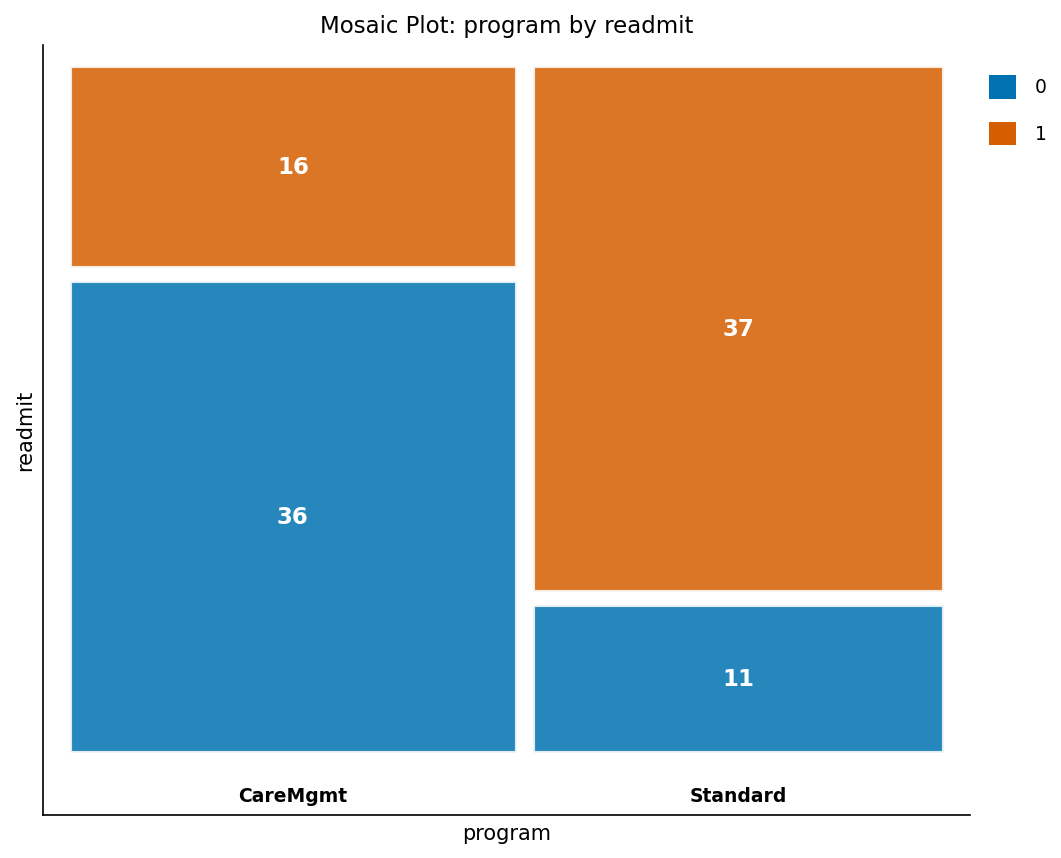

In [2]:
PROCEDIMIENTO FRECUENCIAS DATOS=readmit;
   TABLES program*readmit / nocol nopercent;
   ETIQUETA program = "Programa de Cuidado" readmit = "Reingreso a 30 Días";
EJECUTAR;

PROCEDIMIENTO MEDIAS DATOS=readmit n mean std MIN MAX;
   VAR AGE comorbid visit readmit;
   ETIQUETA AGE = "Edad" comorbid = "Cantidad de Comorbilidades" visit = "Número de Visita"
         readmit = "Reingreso a 30 Días";
EJECUTAR;

## Paso 3 — GEE logístico marginal (correlación de trabajo intercambiable)

La sentencia `REPEATED SUBJECT=patient` declara que las observaciones que comparten un `patient` están correlacionadas. `CORR=EXCH` asume que cada par de visitas dentro de un paciente tiene la misma correlación — una opción por defecto razonable para medidas repetidas sin un orden temporal fuerte. `CORRW` reporta el parámetro de correlación de trabajo estimado. La sentencia `CLASS` incorpora `program` y `sex` como efectos categóricos; el procedimiento usa `CareMgmt` como la referencia del factor, por lo que el coeficiente `factor(program)Standard` reportado es el cambio en log-odds para el **cuidado estándar en relación con la Gestión de Cuidado**.

PROC GEE reporta **ambos** errores estándar, el empírico (sandwich) y el basado en el modelo; los errores empíricos son los que hay que confiar porque siguen siendo válidos incluso si la correlación de trabajo está mal especificada.

In [3]:
PROCEDIMIENTO gee DATOS=readmit;
   CLASE program(REF="Standard") sex;
   MODELO readmit = program sex age_c comorbid visit
                 / DIST=bin LINK=logit;
   REPEATED SUBJECT=patient / CORR=exch CORRW;
   ETIQUETA program = "Programa de Cuidado" sex = "Sexo" age_c = "Edad Centrada"
         comorbid = "Cantidad de Comorbilidades" visit = "Número de Visita"
         readmit = "Reingreso a 30 Días";
EJECUTAR;

                                                   The GEE Procedure                                                    

Model formula: readmit ~ factor(program) + factor(sex) + age_c + comorbid + visit
Dependent Variable: READMIT Reingreso a 30 Días
Distribution: binomial
Link Function: logit
Working Correlation Structure: exchangeable
Correlation Type: Compound Symmetry
Number of Observations Read: 100
Number of Clusters: 25
QIC = 111.768066
QICu = 120.784355

Analysis Of GEE Parameter Estimates
Empirical Standard Error Estimates
Parameter                            Estimate      Std Err          Z   Pr > |Z|
Intercept                           -1.572142     0.781673    -2.0113     0.0443
factor(program)Standard              2.306431     0.466895     4.9399     0.0000
factor(sex)Male                      0.688293     0.617224     1.1151     0.2648
Edad Centrada                        0.763003     0.464270     1.6434     0.1003
Cantidad de Comorbilidades           0.273238     0.2102


NOTE: PROC GEE data=readmit dependent=Some("readmit") dist=Some(Binomial) corr=Some(Exchangeable)

NOTE: PROC GEE wrapper=python


## Paso 4 — El efecto del programa como odds ratio

Los coeficientes del modelo están en la escala logit. Para comunicar el efecto del programa a las partes interesadas clínicas queremos un **odds ratio**. Tomamos la estimación empírica `factor(program)Standard` (**2.306431**) y su error estándar empírico (**0.466895**) del ajuste intercambiable anterior y los exponenciamos en un breve paso DATA: `exp(beta)` es el odds ratio de estándar frente a Gestión de Cuidado, y el odds ratio protector de Gestión de Cuidado frente a Estándar es su recíproco. Un intervalo de confianza de Wald del 95% proviene de `exp(beta +/- 1.96 * SE)`. Esto convierte el coeficiente de regresión en el odds ratio marginal que un pagador o un equipo de calidad reporta.

In [4]:
DATOS program_or;
   /* Estimación empírica (sandwich) para Estándar vs CareMgmt del
      ajuste GEE intercambiable en el Paso 3 (CareMgmt es la referencia). */
   beta = 2.306431;
   se_emp   = 0.466895;
   z    = 1.959964;   /* Percentil 97.5 de la normal estándar */

   /* Cuidado estándar en relación con la Gestión de Cuidado */
   or_standard_vs_care = EXP(beta);
   lcl_standard        = EXP(beta - z*se_emp);
   ucl_standard        = EXP(beta + z*se_emp);

   /* Efecto protector de la Gestión de Cuidado = contraste recíproco */
   or_care_vs_standard = EXP(-beta);
   lcl_care            = EXP(-beta - z*se_emp);
   ucl_care            = EXP(-beta + z*se_emp);

   FORMATO or_standard_vs_care lcl_standard ucl_standard
          or_care_vs_standard lcl_care ucl_care 8.3;
EJECUTAR;

PROCEDIMIENTO IMPRIMIR DATOS=program_or noobs ETIQUETA;
   VAR or_standard_vs_care lcl_standard ucl_standard
       or_care_vs_standard lcl_care ucl_care;
   ETIQUETA or_standard_vs_care = "OR Estándar vs. Cuidado Gestionado"
         lcl_standard        = "LC Inferior (Estándar)"
         ucl_standard        = "LC Superior (Estándar)"
         or_care_vs_standard = "OR Cuidado Gestionado vs. Estándar"
         lcl_care            = "LC Inferior (Cuidado Gestionado)"
         ucl_care            = "LC Superior (Cuidado Gestionado)";
EJECUTAR;


 OR Estándar vs. Cuidado Gestionado   LC Inferior (Estándar)   LC Superior (Estándar)   OR Cuidado Gestionado vs. Estándar  LC Inferior (Cuidado Gestionado)  LC Superior (Cuidado Gestionado)
-----------------------------------  -----------------------  -----------------------  -----------------------------------  --------------------------------  --------------------------------
                             10.039                    4.020                   25.066                                0.100                             0.040                             0.249




NOTE: DATA program_or


NOTE: Wrote program_or (1 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=program_or

NOTE: PROC PRINT completed: 1 observations printed, 6 variables


## Paso 5 — Sensibilidad a la estructura de correlación (AR(1))

Debido a que las visitas están ordenadas en el tiempo, la correlación entre visitas puede decaer con la separación temporal. Reajustamos con una correlación de trabajo **autorregresiva de primer orden**, `CORR=AR(1)`. Los coeficientes de GEE deberían ser estables entre elecciones razonables de correlación; cambios grandes señalarían una sensibilidad que vale la pena investigar. Comparar el criterio de ajuste QIC entre estructuras ayuda a elegir la correlación de trabajo con mejor ajuste.

In [5]:
PROCEDIMIENTO gee DATOS=readmit;
   CLASE program(REF="Standard") sex;
   MODELO readmit = program sex age_c comorbid visit
                 / DIST=bin LINK=logit;
   REPEATED SUBJECT=patient / CORR=ar(1) CORRW;
   ETIQUETA program = "Programa de Cuidado" sex = "Sexo" age_c = "Edad Centrada"
         comorbid = "Cantidad de Comorbilidades" visit = "Número de Visita"
         readmit = "Reingreso a 30 Días";
EJECUTAR;

                                                   The GEE Procedure                                                    

Model formula: readmit ~ factor(program) + factor(sex) + age_c + comorbid + visit
Dependent Variable: READMIT Reingreso a 30 Días
Distribution: binomial
Link Function: logit
Working Correlation Structure: ar1
Correlation Type: First-Order Autoregressive
Number of Observations Read: 100
Number of Clusters: 25
QIC = 123.944817
QICu = 120.792514

Analysis Of GEE Parameter Estimates
Empirical Standard Error Estimates
Parameter                            Estimate      Std Err          Z   Pr > |Z|
Intercept                           -1.585344     0.777886    -2.0380     0.0415
factor(program)Standard              2.314720     0.466627     4.9605     0.0000
factor(sex)Male                      0.714028     0.613258     1.1643     0.2443
Edad Centrada                        0.795159     0.464005     1.7137     0.0866
Cantidad de Comorbilidades           0.266728     0.2089


NOTE: PROC GEE data=readmit dependent=Some("readmit") dist=Some(Binomial) corr=Some(Ar1)

NOTE: PROC GEE wrapper=r


## Interpretación de los resultados

- **La correlación dentro del paciente es positiva.** El parámetro de correlación de trabajo intercambiable es **alpha = 0.058** (AR(1): **0.095**), confirmando que los desenlaces repetidos de reingreso en el mismo paciente se mueven juntos. Ignorarla (regresión logística ordinaria) subestimaría los errores estándar y sobrestimaría la significancia.
- **SE empírico vs. basado en el modelo.** PROC GEE reporta ambos; la inferencia aquí se basa en los errores estándar **empíricos (sandwich)**, que siguen siendo válidos incluso si la correlación de trabajo está mal especificada. Para el efecto del programa, el SE empírico es **0.467** frente a un SE basado en el modelo de **0.566**.
- **El efecto del programa.** El coeficiente `factor(program)Standard` es **+2.306** (Z = 4.94, p < 0.0001): los pacientes de cuidado estándar tienen probabilidades promediadas sobre la población de reingreso a 30 días sustancialmente más altas que los pacientes de Gestión de Cuidado. El Paso 4 traduce esto en un **odds ratio de Gestión de Cuidado frente a Estándar de 0.10 (IC de Wald del 95% de 0.040 a 0.249)** — un gran efecto protector cuyo intervalo excluye 1, por lo que es estadísticamente distinguible de ningún efecto. La tabulación cruzada bruta concuerda: **31% de las visitas de pacientes de Gestión de Cuidado terminaron en reingreso (16/52) frente a 77% bajo cuidado estándar (37/48)**.
- **Otros factores.** La edad (coeficiente +0.76) y la cantidad de comorbilidades (+0.27) aumentan las probabilidades de reingreso, mientras que el riesgo desciende levemente a través de las visitas (-0.07) — consistente con el mecanismo generador de datos, aunque solo el efecto del programa es individualmente significativo con este tamaño de muestra.
- **Elección de la estructura.** Los ajustes intercambiable y AR(1) dan coeficientes del programa casi idénticos (**+2.306** frente a **+2.315**), por lo que las conclusiones sobre el efecto del programa no son un artefacto de la correlación asumida. La estructura intercambiable tiene el **QIC** más bajo (111.77 frente a 123.94), por lo que es la correlación de trabajo con mejor ajuste aquí.

**Conclusión:** PROC GEE entrega una estimación defendible, promediada sobre la población, del efecto de un programa de cuidado sobre un desenlace binario correlacionado — exactamente la interpretación marginal que un pagador o un equipo de mejora de calidad necesita, con errores estándar que respetan el diseño de medidas repetidas.